# 05 - Motor restringido de recomendaciones

## 1. Dependencias

In [1]:
#Instalar dependencias
%pip install pandas numpy scikit-learn matplotlib joblib

Note: you may need to restart the kernel to use updated packages.


## 2. Configuración

In [2]:
#Librerías
import platform
import sys
from pathlib import Path
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [3]:
#Configuración
SEMILLA = 20260727
UMBRAL_ESTADO = 0.50
UMBRAL_RECOMENDACION = 0.50
COBERTURA_ESENCIAL_MINIMA_MESES = 1.0
VERSION_MODELO = 'fincoah_recomendaciones_mvp_v1'

ruta_decisiones = Path('../Datasets/decisiones_recomendaciones.csv')
ruta_trayectorias = Path('../Datasets/trayectorias_financieras.csv')
ruta_perfiles = Path('../Datasets/perfil_integral_usuario.csv')
ruta_estados_ventana = Path('../Resultados/04_estados_por_ventana.csv')
ruta_estados_actuales = Path('../Resultados/04_estados_trayectoria.csv')
ruta_modelo = Path('../Modelos/05_motor_recomendaciones.joblib')
ruta_resultados = Path('../Resultados')
ruta_graficas = ruta_resultados / 'Graficas'

versiones = pd.DataFrame([
    {'componente': 'python', 'version': sys.version.split()[0]},
    {'componente': 'pandas', 'version': pd.__version__},
    {'componente': 'numpy', 'version': np.__version__},
    {'componente': 'scikit-learn', 'version': sklearn.__version__},
    {'componente': 'matplotlib', 'version': matplotlib.__version__},
    {'componente': 'sistema', 'version': platform.platform()},
])

display(versiones)

,componente,version
0,python,3.14.3
1,pandas,3.0.3
2,numpy,2.5.1
3,scikit-learn,1.9.0
4,matplotlib,3.11.1
5,sistema,macOS-26.5.2-arm64-arm-64bit-Mach-O


## 3. Carga de productos anteriores

In [4]:
#Cargar datos
decisiones = pd.read_csv(ruta_decisiones, low_memory=False)
trayectorias = pd.read_csv(ruta_trayectorias, low_memory=False)
perfiles = pd.read_csv(ruta_perfiles, low_memory=False)
estados_ventana = pd.read_csv(ruta_estados_ventana, low_memory=False)
estados_actuales = pd.read_csv(ruta_estados_actuales, low_memory=False)

for columna in ['fecha_decision']:
    decisiones[columna] = pd.to_datetime(decisiones[columna], errors='coerce')

for columna in ['fecha_corte', 'periodo_desde', 'periodo_hasta']:
    trayectorias[columna] = pd.to_datetime(trayectorias[columna], errors='coerce')
    if columna in estados_ventana.columns:
        estados_ventana[columna] = pd.to_datetime(estados_ventana[columna], errors='coerce')
    if columna in estados_actuales.columns:
        estados_actuales[columna] = pd.to_datetime(estados_actuales[columna], errors='coerce')

resumen_fuentes = pd.DataFrame([
    {'fuente': 'decisiones', 'filas': len(decisiones), 'perfiles': decisiones['perfil_id'].nunique()},
    {'fuente': 'trayectorias', 'filas': len(trayectorias), 'perfiles': trayectorias['perfil_id'].nunique()},
    {'fuente': 'estados por ventana', 'filas': len(estados_ventana), 'perfiles': estados_ventana['perfil_id'].nunique()},
    {'fuente': 'estados actuales', 'filas': len(estados_actuales), 'perfiles': estados_actuales['perfil_id'].nunique()},
])

display(resumen_fuentes)
display(decisiones.head(5))


,fuente,filas,perfiles
0,decisiones,600,200
1,trayectorias,600,200
2,estados por ventana,600,200
3,estados actuales,200,200


,decision_id,perfil_id,estado_alcance_mvp,ventana_id,fecha_decision,estado_trayectoria,recomendacion_id,recomendacion,tipo_recomendacion,meta_relacionada,...,razon_decision,evidencia_utilizada,riesgo_si_se_aplica,revision_humana,particion,historia_financiera_controlada,es_sintetico,version_catalogo,version_esquema,huella_registro
0,DEC_0001_04,PERF_0001,dentro_del_mvp,VEN_0001_1,2026-04-30,acumulacion_estable,REC_MANTENER_ACUMULACION,Mantener el patrón actual y separar automática...,mantenimiento_y_ahorro,crear_fondo_emergencia,...,El estado acumulacion_estable describe únicame...,VEN_0001_1 | balance_operativo_no_negativo | c...,bajo,no_requerida,train,acumulacion_estable,si,recomendaciones_mvp_v1.1,fincoah_mvp_co_v1.1,6987e127752aff2929a3d7ceeee9ddb5f4b7a3b1bb346a...
1,DEC_0001_05,PERF_0001,dentro_del_mvp,VEN_0001_2,2026-05-31,acumulacion_estable,REC_MANTENER_ACUMULACION,Mantener el patrón actual y separar automática...,mantenimiento_y_ahorro,crear_fondo_emergencia,...,El estado acumulacion_estable describe únicame...,VEN_0001_2 | balance_operativo_no_negativo | c...,bajo,no_requerida,train,acumulacion_estable,si,recomendaciones_mvp_v1.1,fincoah_mvp_co_v1.1,3d892c9e52a5a3e0f8d8b768ebe9e1bdce96784d72376c...
2,DEC_0001_06,PERF_0001,dentro_del_mvp,VEN_0001_3,2026-06-30,acumulacion_estable,REC_MANTENER_ACUMULACION,Mantener el patrón actual y separar automática...,mantenimiento_y_ahorro,crear_fondo_emergencia,...,El estado acumulacion_estable describe únicame...,VEN_0001_3 | balance_operativo_no_negativo | c...,bajo,no_requerida,train,acumulacion_estable,si,recomendaciones_mvp_v1.1,fincoah_mvp_co_v1.1,162bc977fdc008cf86f0f1278072022776a51582e9a642...
3,DEC_0002_04,PERF_0002,dentro_del_mvp,VEN_0002_1,2026-04-30,equilibrio_sostenible,REC_CREAR_MARGEN,Crear un margen pequeño y flexible antes de au...,prevencion,ampliar_actividad_economica,...,El estado equilibrio_sostenible describe única...,VEN_0002_1 | balance_operativo_no_negativo | c...,bajo,no_requerida,train,equilibrio_sostenible,si,recomendaciones_mvp_v1.1,fincoah_mvp_co_v1.1,abee50cf7354e28f3a2ba7e57af883cf27751816917753...
4,DEC_0002_05,PERF_0002,dentro_del_mvp,VEN_0002_2,2026-05-31,equilibrio_sostenible,REC_CREAR_MARGEN,Crear un margen pequeño y flexible antes de au...,prevencion,ampliar_actividad_economica,...,El estado equilibrio_sostenible describe única...,VEN_0002_2 | balance_operativo_no_negativo | c...,bajo,no_requerida,train,equilibrio_sostenible,si,recomendaciones_mvp_v1.1,fincoah_mvp_co_v1.1,3ea16c5761c7781347ac2d8aa03e7f5a995a2b31a6503e...


## 4. Contrato y trazabilidad

In [5]:
#Validar contrato
columnas_decision = [
    'decision_id',
    'perfil_id',
    'ventana_id',
    'estado_trayectoria',
    'recomendacion_id',
    'recomendacion',
    'tipo_recomendacion',
    'decision',
    'prioridad',
    'requiere_confirmacion',
    'condiciones_exclusion',
    'riesgo_si_se_aplica',
    'revision_humana',
    'particion',
]

columnas_faltantes = sorted(set(columnas_decision) - set(decisiones.columns))
perfiles_por_particion = decisiones.groupby('perfil_id')['particion'].nunique()
estados_por_ventana = estados_ventana['ventana_id'].value_counts()
errores_contrato = pd.DataFrame([
    {'control': 'columnas requeridas', 'errores': len(columnas_faltantes)},
    {'control': 'decisiones duplicadas', 'errores': int(decisiones['decision_id'].duplicated().sum())},
    {'control': 'ventanas duplicadas en estados', 'errores': int(estados_por_ventana.ne(1).sum())},
    {'control': 'perfil en una sola partición', 'errores': int(perfiles_por_particion.gt(1).sum())},
    {'control': 'particiones válidas', 'errores': int((~decisiones['particion'].isin(['train', 'validation', 'test'])).sum())},
    {'control': 'fecha de decisión válida', 'errores': int(decisiones['fecha_decision'].isna().sum())},
])

display(errores_contrato)
assert not columnas_faltantes, f'Faltan columnas: {columnas_faltantes}'
assert errores_contrato['errores'].eq(0).all(), 'El contrato de recomendaciones contiene errores'

,control,errores
0,columnas requeridas,0
1,decisiones duplicadas,0
2,ventanas duplicadas en estados,0
3,perfil en una sola partición,0
4,particiones válidas,0
5,fecha de decisión válida,0


In [7]:
#Unir estados y decisiones
columnas_estado = [
    'ventana_id',
    'perfil_id',
    'estado_modelo',
    'estado_calculo_modelo',
    'confianza_pct',
    'particion',
]
columnas_probabilidad = sorted([
    columna
    for columna in estados_ventana.columns
    if columna.startswith('prob_') and columna.endswith('_pct')
])

datos = decisiones.merge(
    estados_ventana[columnas_estado + columnas_probabilidad],
    on=['ventana_id', 'perfil_id', 'particion'],
    how='left',
    validate='one_to_one',
)

errores_union = pd.DataFrame([
    {'control': 'estado del notebook 04 disponible', 'errores': int(datos['estado_modelo'].isna().sum())},
    {'control': 'siete porcentajes disponibles', 'errores': abs(len(columnas_probabilidad) - 7)},
    {'control': 'partición conservada', 'errores': int(datos['particion'].isna().sum())},
])

display(errores_union)
assert errores_union['errores'].eq(0).all(), 'La unión con los estados del notebook 04 falló'

,control,errores
0,estado del notebook 04 disponible,0
1,siete porcentajes disponibles,0
2,partición conservada,0


## 5. Alcance real del catálogo

In [8]:
#Auditar catálogo
recomendacion_por_estado = datos.groupby('estado_trayectoria')['recomendacion_id'].nunique()
estado_por_recomendacion = datos.groupby('recomendacion_id')['estado_trayectoria'].nunique()
cobertura_recomendaciones = pd.crosstab(
    datos['recomendacion_id'],
    datos['particion'],
).reindex(columns=['train', 'validation', 'test'], fill_value=0)

correspondencia_catalogo = datos[[
    'estado_trayectoria',
    'recomendacion_id',
    'tipo_recomendacion',
    'decision',
    'prioridad',
    'revision_humana',
]].drop_duplicates().sort_values('estado_trayectoria')

display(correspondencia_catalogo)
display(cobertura_recomendaciones)

assert recomendacion_por_estado.eq(1).all(), 'Un estado tiene más de una recomendación en el catálogo'
assert estado_por_recomendacion.eq(1).all(), 'Una recomendación pertenece a varios estados'
assert cobertura_recomendaciones.gt(0).all().all(), 'Alguna recomendación no aparece en todas las particiones'

,estado_trayectoria,recomendacion_id,tipo_recomendacion,decision,prioridad,revision_humana
0,acumulacion_estable,REC_MANTENER_ACUMULACION,mantenimiento_y_ahorro,aplicar,media,no_requerida
14,deterioro_reciente,REC_REVISAR_CAMBIO_RECIENTE,diagnostico,solicitar_contexto,alta,no_requerida
3,equilibrio_sostenible,REC_CREAR_MARGEN,prevencion,sugerir,media,no_requerida
16,fragilidad_sostenida,REC_PRIORIZAR_COBERTURA,proteccion_esencial,aplicar,alta,no_requerida
19,situacion_critica,REC_PLAN_CONTENCION,contencion_y_revision,aplicar,critica,requerida
10,uso_planificado_reserva,REC_VIGILAR_RESERVA,seguimiento_meta,sugerir,media,no_requerida
7,variable_resiliente,REC_RESERVA_PICOS,gestion_ingreso_variable,aplicar,alta,no_requerida


particion,train,validation,test
recomendacion_id,,,
REC_CREAR_MARGEN,120,25,27
REC_MANTENER_ACUMULACION,80,19,17
REC_PLAN_CONTENCION,38,10,8
REC_PRIORIZAR_COBERTURA,59,13,12
REC_RESERVA_PICOS,42,8,8
REC_REVISAR_CAMBIO_RECIENTE,41,7,8
REC_VIGILAR_RESERVA,40,8,10


In [9]:
#Definir guardas
guardas_eticas = pd.DataFrame([
    {'guarda': 'evidencia insuficiente', 'accion': 'abstenerse', 'motivo': 'no producir consejo con historia incompleta'},
    {'guarda': 'confianza del estado menor al 50 %', 'accion': 'abstenerse', 'motivo': 'no convertir incertidumbre en certeza'},
    {'guarda': 'cobertura esencial menor a un mes', 'accion': 'priorizar cobertura', 'motivo': 'proteger vivienda, alimentación, salud y servicios'},
    {'guarda': 'situación crítica', 'accion': 'plan de contención con revisión', 'motivo': 'evitar automatización de una decisión sensible'},
    {'guarda': 'deterioro reciente', 'accion': 'revisión humana', 'motivo': 'no asumir que un cambio reciente es permanente'},
    {'guarda': 'hobbies declarados', 'accion': 'conservar en contexto', 'motivo': 'no eliminarlos automáticamente'},
    {'guarda': 'ingreso variable', 'accion': 'no declarar riesgo por sí solo', 'motivo': 'evaluar recuperación y cobertura'},
])

display(guardas_eticas)

,guarda,accion,motivo
0,evidencia insuficiente,abstenerse,no producir consejo con historia incompleta
1,confianza del estado menor al 50 %,abstenerse,no convertir incertidumbre en certeza
2,cobertura esencial menor a un mes,priorizar cobertura,"proteger vivienda, alimentación, salud y servi..."
3,situación crítica,plan de contención con revisión,evitar automatización de una decisión sensible
4,deterioro reciente,revisión humana,no asumir que un cambio reciente es permanente
5,hobbies declarados,conservar en contexto,no eliminarlos automáticamente
6,ingreso variable,no declarar riesgo por sí solo,evaluar recuperación y cobertura


## 6. Variables y particiones

In [10]:
#Preparar variables
variable_categorica = ['estado_modelo']
variables_numericas = columnas_probabilidad
variables_modelo = variable_categorica + variables_numericas

X = datos[variables_modelo].copy()
y = datos['recomendacion_id']
mascara_train = datos['particion'].eq('train')
mascara_validation = datos['particion'].eq('validation')
mascara_test = datos['particion'].eq('test')

X_train = X.loc[mascara_train]
y_train = y.loc[mascara_train]
X_validation = X.loc[mascara_validation]
y_validation = y.loc[mascara_validation]
X_test = X.loc[mascara_test]
y_test = y.loc[mascara_test]

resumen_particiones = pd.DataFrame([
    {'particion': 'train', 'filas': len(X_train), 'perfiles': datos.loc[mascara_train, 'perfil_id'].nunique()},
    {'particion': 'validation', 'filas': len(X_validation), 'perfiles': datos.loc[mascara_validation, 'perfil_id'].nunique()},
    {'particion': 'test', 'filas': len(X_test), 'perfiles': datos.loc[mascara_test, 'perfil_id'].nunique()},
])

display(resumen_particiones)

,particion,filas,perfiles
0,train,420,140
1,validation,90,30
2,test,90,30


## 7. Entrenamiento supervisado

In [11]:
#Definir preprocesador
preprocesador = ColumnTransformer([
    (
        'estado',
        OneHotEncoder(handle_unknown='ignore', sparse_output=False),
        variable_categorica,
    ),
    (
        'porcentajes',
        Pipeline([
            ('faltantes', SimpleImputer(strategy='median')),
            ('escala', StandardScaler()),
        ]),
        variables_numericas,
    ),
])

modelos_candidatos = {
    'regresion_logistica': Pipeline([
        ('preparacion', preprocesador),
        ('modelo', LogisticRegression(
            C=1.0,
            max_iter=5000,
            class_weight='balanced',
            random_state=SEMILLA,
        )),
    ]),
    'bosque_aleatorio': Pipeline([
        ('preparacion', preprocesador),
        ('modelo', RandomForestClassifier(
            n_estimators=500,
            max_depth=10,
            min_samples_leaf=2,
            max_features='sqrt',
            class_weight='balanced_subsample',
            random_state=SEMILLA,
            n_jobs=-1,
        )),
    ]),
}

In [12]:
#Comparar modelos
metricas_validation = []

for nombre, modelo in modelos_candidatos.items():
    modelo.fit(X_train, y_train)
    prediccion = modelo.predict(X_validation)
    probabilidades = modelo.predict_proba(X_validation)
    metricas_validation.append({
        'modelo': nombre,
        'accuracy': round(accuracy_score(y_validation, prediccion), 4),
        'balanced_accuracy': round(balanced_accuracy_score(y_validation, prediccion), 4),
        'f1_macro': round(f1_score(y_validation, prediccion, average='macro'), 4),
        'log_loss': round(log_loss(y_validation, probabilidades, labels=modelo.classes_), 4),
    })

metricas_validation = pd.DataFrame(metricas_validation).sort_values(
    ['f1_macro', 'log_loss'],
    ascending=[False, True],
).reset_index(drop=True)
nombre_modelo_final = metricas_validation.loc[0, 'modelo']

display(metricas_validation)
print(f'Modelo seleccionado: {nombre_modelo_final}')

,modelo,accuracy,balanced_accuracy,f1_macro,log_loss
0,bosque_aleatorio,1.0,1.0,1.0,0.0063
1,regresion_logistica,1.0,1.0,1.0,0.0121


Modelo seleccionado: bosque_aleatorio


In [13]:
#Evaluar modelo final
mascara_desarrollo = mascara_train | mascara_validation
modelo_final = clone(modelos_candidatos[nombre_modelo_final])
modelo_final.fit(X.loc[mascara_desarrollo], y.loc[mascara_desarrollo])

prediccion_test = modelo_final.predict(X_test)
probabilidades_test = modelo_final.predict_proba(X_test)
metricas_test = pd.DataFrame([{
    'modelo': nombre_modelo_final,
    'accuracy': round(accuracy_score(y_test, prediccion_test), 4),
    'balanced_accuracy': round(balanced_accuracy_score(y_test, prediccion_test), 4),
    'f1_macro': round(f1_score(y_test, prediccion_test, average='macro'), 4),
    'log_loss': round(log_loss(y_test, probabilidades_test, labels=modelo_final.classes_), 4),
}])

reporte_test = pd.DataFrame(classification_report(
    y_test,
    prediccion_test,
    output_dict=True,
    zero_division=0,
)).T.round(4)

display(metricas_test)
display(reporte_test)

,modelo,accuracy,balanced_accuracy,f1_macro,log_loss
0,bosque_aleatorio,0.9778,0.9702,0.9675,0.0743


,precision,recall,f1-score,support
REC_CREAR_MARGEN,1.0000,1.0000,1.0000,27.0000
REC_MANTENER_ACUMULACION,1.0000,1.0000,1.0000,17.0000
REC_PLAN_CONTENCION,0.8889,1.0000,0.9412,8.0000
REC_PRIORIZAR_COBERTURA,1.0000,0.9167,0.9565,12.0000
REC_RESERVA_PICOS,1.0000,0.8750,0.9333,8.0000
REC_REVISAR_CAMBIO_RECIENTE,0.8889,1.0000,0.9412,8.0000
REC_VIGILAR_RESERVA,1.0000,1.0000,1.0000,10.0000
accuracy,0.9778,0.9778,0.9778,0.9778
macro avg,0.9683,0.9702,0.9675,90.0000
weighted avg,0.9802,0.9778,0.9778,90.0000


## 8. Evaluación visual

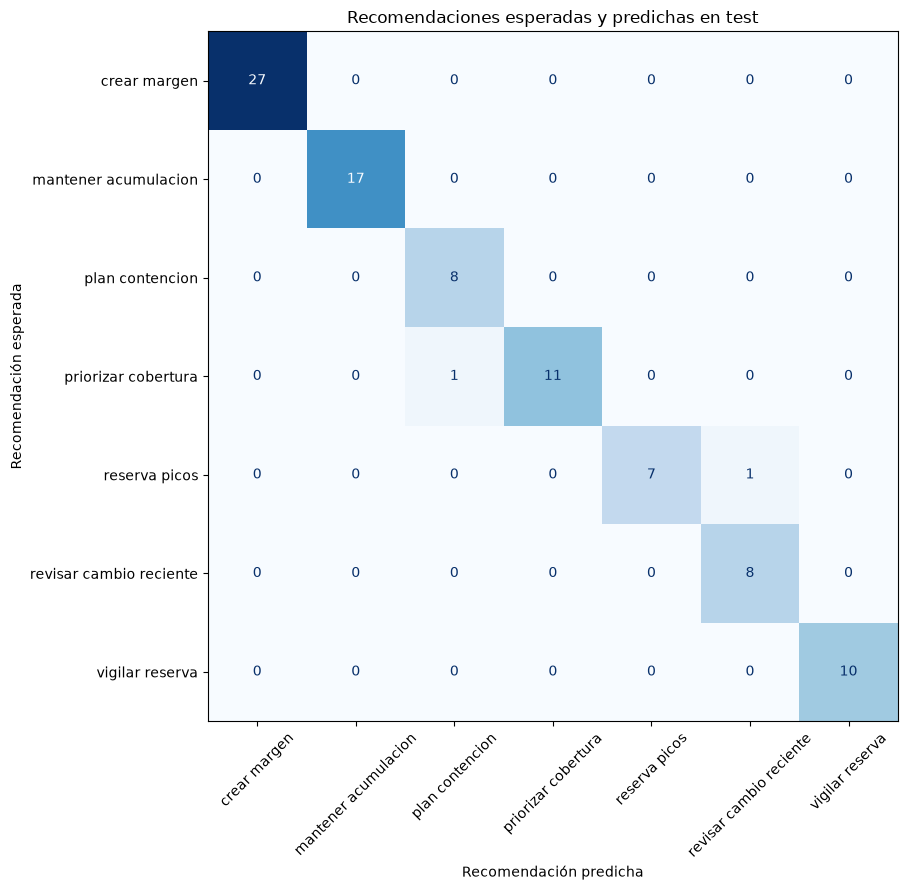

In [14]:
#Mostrar matriz de confusión
etiquetas_recomendacion = sorted(y.unique())
etiquetas_cortas = [etiqueta.replace('REC_', '').replace('_', ' ').lower() for etiqueta in etiquetas_recomendacion]
figura, eje = plt.subplots(figsize=(12, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    prediccion_test,
    labels=etiquetas_recomendacion,
    display_labels=etiquetas_cortas,
    cmap='Blues',
    colorbar=False,
    xticks_rotation=45,
    ax=eje,
)

eje.set_title('Recomendaciones esperadas y predichas en test')
eje.set_xlabel('Recomendación predicha')
eje.set_ylabel('Recomendación esperada')
figura.tight_layout()

ruta_graficas.mkdir(parents=True, exist_ok=True)
figura.savefig(ruta_graficas / '05_matriz_confusion_recomendaciones.png', dpi=180, bbox_inches='tight')
plt.show()

In [15]:
#Mostrar importancia
preparacion_final = modelo_final.named_steps['preparacion']
estimador_final = modelo_final.named_steps['modelo']
nombres_transformados = preparacion_final.get_feature_names_out()

if hasattr(estimador_final, 'feature_importances_'):
    valores_importancia = estimador_final.feature_importances_
else:
    valores_importancia = np.abs(estimador_final.coef_).mean(axis=0)

importancia_variables = pd.DataFrame({
    'variable': nombres_transformados,
    'importancia': valores_importancia,
}).sort_values('importancia', ascending=False)

display(importancia_variables)

,variable,importancia
9,porcentajes__prob_equilibrio_sostenible_pct,0.080780
12,porcentajes__prob_uso_planificado_reserva_pct,0.079480
8,porcentajes__prob_deterioro_reciente_pct,0.078450
7,porcentajes__prob_acumulacion_estable_pct,0.077013
13,porcentajes__prob_variable_resiliente_pct,0.073993
10,porcentajes__prob_fragilidad_sostenida_pct,0.072328
11,porcentajes__prob_situacion_critica_pct,0.070939
3,estado__estado_modelo_fragilidad_sostenida,0.070325
2,estado__estado_modelo_equilibrio_sostenible,0.068838
6,estado__estado_modelo_variable_resiliente,0.067100


## 9. Catálogo y motor de guardas

In [16]:
#Construir catálogo
campos_estables_catalogo = [
    'recomendacion_id',
    'recomendacion',
    'tipo_recomendacion',
    'decision',
    'prioridad',
    'requiere_confirmacion',
    'condiciones_exclusion',
    'riesgo_si_se_aplica',
    'revision_humana',
]

controles_catalogo = datos.groupby('recomendacion_id')[campos_estables_catalogo[1:]].nunique(dropna=False)
catalogo_recomendaciones = datos[campos_estables_catalogo].drop_duplicates('recomendacion_id').set_index('recomendacion_id')

display(catalogo_recomendaciones.reset_index())
assert controles_catalogo.le(1).all().all(), 'El catálogo contiene definiciones contradictorias'

,recomendacion_id,recomendacion,tipo_recomendacion,decision,prioridad,requiere_confirmacion,condiciones_exclusion,riesgo_si_se_aplica,revision_humana
0,REC_MANTENER_ACUMULACION,Mantener el patrón actual y separar automática...,mantenimiento_y_ahorro,aplicar,media,no,no_declarar_riesgo_solo_por_ingreso_variable |...,bajo,no_requerida
1,REC_CREAR_MARGEN,Crear un margen pequeño y flexible antes de au...,prevencion,sugerir,media,no,no_declarar_riesgo_solo_por_ingreso_variable |...,bajo,no_requerida
2,REC_RESERVA_PICOS,Reservar parte de los meses altos para cubrir ...,gestion_ingreso_variable,aplicar,alta,no,no_declarar_riesgo_solo_por_ingreso_variable |...,bajo,no_requerida
3,REC_VIGILAR_RESERVA,Mantener el gasto alineado con la meta y revis...,seguimiento_meta,sugerir,media,no,no_declarar_riesgo_solo_por_ingreso_variable |...,bajo,no_requerida
4,REC_REVISAR_CAMBIO_RECIENTE,Revisar el cambio reciente en ingresos y compr...,diagnostico,solicitar_contexto,alta,si,no_declarar_riesgo_solo_por_ingreso_variable |...,podria_reducir_bienestar_o_desconocer_el_contexto,no_requerida
5,REC_PRIORIZAR_COBERTURA,"Priorizar vivienda, alimentación, salud y serv...",proteccion_esencial,aplicar,alta,no,no_declarar_riesgo_solo_por_ingreso_variable |...,podria_reducir_bienestar_o_desconocer_el_contexto,no_requerida
6,REC_PLAN_CONTENCION,Activar un plan de contención centrado en nece...,contencion_y_revision,aplicar,critica,no,no_declarar_riesgo_solo_por_ingreso_variable |...,podria_reducir_bienestar_o_desconocer_el_contexto,requerida


In [17]:
#Definir motor
estados_validos = set(datos['estado_trayectoria'].unique())

def revisar_entrada_motor(entrada):
    motivos = []
    estado_calculo = entrada.get('estado_calculo_modelo')
    estado = entrada.get('estado_modelo')
    confianza = entrada.get('confianza_pct')
    cobertura = entrada.get('cobertura_esencial_L_meses')

    if estado_calculo != 'calculado':
        motivos.append('estado_financiero_sin_evidencia_suficiente')
    if estado not in estados_validos:
        motivos.append('estado_fuera_del_catalogo')
    if pd.isna(confianza) or float(confianza) < UMBRAL_ESTADO * 100:
        motivos.append('confianza_del_estado_insuficiente')
    if pd.isna(cobertura):
        motivos.append('cobertura_esencial_no_calculable')

    probabilidades_faltantes = [
        columna
        for columna in columnas_probabilidad
        if columna not in entrada or pd.isna(entrada[columna])
    ]
    if probabilidades_faltantes:
        motivos.append('porcentajes_de_estado_incompletos')
    else:
        suma = sum(float(entrada[columna]) for columna in columnas_probabilidad)
        if not np.isclose(suma, 100.0, atol=1.0):
            motivos.append('porcentajes_de_estado_no_reconcilian')

    return motivos

def aplicar_guardas(recomendacion_id, entrada):
    estado = entrada['estado_modelo']
    cobertura = float(entrada['cobertura_esencial_L_meses'])
    guardas_aplicadas = []
    recomendacion_final = recomendacion_id

    if estado == 'situacion_critica':
        recomendacion_final = 'REC_PLAN_CONTENCION'
        guardas_aplicadas.append('situacion_critica_con_revision_humana')
    elif estado == 'fragilidad_sostenida':
        recomendacion_final = 'REC_PRIORIZAR_COBERTURA'
        guardas_aplicadas.append('proteccion_esencial_por_fragilidad')
    elif cobertura < COBERTURA_ESENCIAL_MINIMA_MESES:
        recomendacion_final = 'REC_PRIORIZAR_COBERTURA'
        guardas_aplicadas.append('cobertura_esencial_menor_a_un_mes')

    if estado == 'deterioro_reciente':
        guardas_aplicadas.append('cambio_reciente_requiere_revision')
    if entrada.get('hobbies_considerados') not in [None, '', 'no_declarado']:
        guardas_aplicadas.append('hobbies_no_eliminados_automaticamente')

    return recomendacion_final, guardas_aplicadas

def construir_razon(entrada, recomendacion_id, guardas_aplicadas):
    periodo_desde = entrada.get('periodo_desde', 'no_disponible')
    periodo_hasta = entrada.get('periodo_hasta', 'no_disponible')
    estado = entrada.get('estado_modelo', 'no_disponible')
    meta = entrada.get('meta_relacionada', 'no_declarada')
    meta = 'no_declarada' if pd.isna(meta) or not str(meta).strip() else meta
    guardas = ' | '.join(guardas_aplicadas) if guardas_aplicadas else 'sin_guarda_adicional'
    return (
        f'La recomendación {recomendacion_id} se limita al estado {estado} observado entre '
        f'{periodo_desde} y {periodo_hasta}. Meta declarada: {meta}. Guardas: {guardas}.'
    )

def generar_recomendacion(entrada):
    motivos = revisar_entrada_motor(entrada)

    if motivos:
        return {
            'estado_motor': 'abstencion',
            'recomendacion_id': 'no_disponible',
            'recomendacion_candidata_modelo': 'no_disponible',
            'fuente_seleccion': 'abstencion_por_evidencia',
            'recomendacion': 'No se genera una recomendación con la evidencia disponible.',
            'decision': 'abstener',
            'prioridad': 'no_aplica',
            'confianza_recomendacion_pct': np.nan,
            'confianza_candidata_modelo_pct': np.nan,
            'revision_humana': 'no_aplica',
            'motivos': motivos,
            'guardas_aplicadas': [],
            'porcentajes_recomendacion': {},
        }

    fila_modelo = pd.DataFrame([entrada])[variables_modelo]
    probabilidades = modelo_final.predict_proba(fila_modelo)[0]
    posicion = int(np.argmax(probabilidades))
    confianza = float(probabilidades[posicion])
    candidata = modelo_final.classes_[posicion]
    porcentajes = {
        recomendacion: round(float(probabilidad) * 100, 2)
        for recomendacion, probabilidad in sorted(
            zip(modelo_final.classes_, probabilidades),
            key=lambda elemento: elemento[1],
            reverse=True,
        )
    }

    if confianza < UMBRAL_RECOMENDACION:
        return {
            'estado_motor': 'abstencion',
            'recomendacion_id': 'no_disponible',
            'recomendacion_candidata_modelo': candidata,
            'fuente_seleccion': 'abstencion_por_confianza',
            'recomendacion': 'Ninguna recomendación alcanzó la confianza mínima.',
            'decision': 'abstener',
            'prioridad': 'no_aplica',
            'confianza_recomendacion_pct': round(confianza * 100, 2),
            'confianza_candidata_modelo_pct': round(confianza * 100, 2),
            'revision_humana': 'no_aplica',
            'motivos': ['confianza_de_recomendacion_insuficiente'],
            'guardas_aplicadas': [],
            'porcentajes_recomendacion': porcentajes,
        }

    recomendacion_final, guardas_aplicadas = aplicar_guardas(candidata, entrada)
    ficha = catalogo_recomendaciones.loc[recomendacion_final]
    razon = construir_razon(entrada, recomendacion_final, guardas_aplicadas)
    confianza_final = porcentajes.get(recomendacion_final, 0.0)
    modificada_por_guarda = recomendacion_final != candidata
    fuente_seleccion = 'guarda_etica' if modificada_por_guarda else 'modelo_restringido'
    revision_humana = ficha['revision_humana']

    if entrada['estado_modelo'] in ['situacion_critica', 'deterioro_reciente']:
        revision_humana = 'requerida'

    return {
        'estado_motor': 'recomendacion_disponible',
        'recomendacion_id': recomendacion_final,
        'recomendacion_candidata_modelo': candidata,
        'fuente_seleccion': fuente_seleccion,
        'recomendacion': ficha['recomendacion'],
        'tipo_recomendacion': ficha['tipo_recomendacion'],
        'decision': ficha['decision'],
        'prioridad': ficha['prioridad'],
        'confianza_recomendacion_pct': confianza_final,
        'confianza_candidata_modelo_pct': round(confianza * 100, 2),
        'revision_humana': revision_humana,
        'razon_decision': razon,
        'aspectos_protegidos': entrada.get('aspectos_protegidos', 'necesidades_esenciales'),
        'hobbies_considerados': entrada.get('hobbies_considerados', 'no_declarado'),
        'meta_relacionada': entrada.get('meta_relacionada', 'no_declarada'),
        'condiciones_exclusion': ficha['condiciones_exclusion'],
        'riesgo_si_se_aplica': ficha['riesgo_si_se_aplica'],
        'motivos': [],
        'guardas_aplicadas': guardas_aplicadas,
        'porcentajes_recomendacion': porcentajes,
    }

## 10. Recomendaciones actuales

In [18]:
#Preparar perfiles actuales
ultimas_trayectorias = trayectorias.sort_values('fecha_corte').groupby('perfil_id').tail(1)[[
    'ventana_id',
    'perfil_id',
    'periodo_desde',
    'periodo_hasta',
    'cobertura_esencial_L_meses',
]]

contexto_perfiles = perfiles[[
    'perfil_id',
    'meta_declarada',
    'hobby_1',
    'hobby_2',
    'responsabilidad_declarada',
]]

perfiles_motor = estados_actuales.merge(
    ultimas_trayectorias,
    on=['ventana_id', 'perfil_id', 'periodo_desde', 'periodo_hasta'],
    how='left',
    validate='one_to_one',
).merge(
    contexto_perfiles,
    on='perfil_id',
    how='left',
    validate='many_to_one',
)

display(perfiles_motor.head(5))
assert perfiles_motor['cobertura_esencial_L_meses'].notna().all(), 'Falta cobertura esencial en perfiles actuales'

,ventana_id,perfil_id,fecha_corte,periodo_desde,periodo_hasta,estado_esperado,estado_modelo,estado_calculo_modelo,confianza_pct,nivel_incertidumbre_modelo,...,prob_uso_planificado_reserva_pct,regularidades_observadas,eventos_inusuales_observados,tendencia_entradas,tendencia_salidas,cobertura_esencial_L_meses,meta_declarada,hobby_1,hobby_2,responsabilidad_declarada
0,VEN_0164_3,PERF_0164,2026-06-30,2026-04-01,2026-06-30,variable_resiliente,variable_resiliente,calculado,64.19,media,...,4.42,2,4.0,estabilidad_observada,estabilidad_observada,0.0000,NaN,musica,NaN,NaN
1,VEN_0172_3,PERF_0172,2026-06-30,2026-04-01,2026-06-30,uso_planificado_reserva,uso_planificado_reserva,calculado,87.05,baja,...,87.05,2,4.0,disminucion_observada,aumento_observado,1.8310,NaN,cocina_y_reposteria,videojuegos_y_streaming,NaN
2,VEN_0167_3,PERF_0167,2026-06-30,2026-04-01,2026-06-30,fragilidad_sostenida,fragilidad_sostenida,calculado,96.79,baja,...,0.86,3,2.0,disminucion_observada,estabilidad_observada,0.0000,comprar_equipo_de_trabajo,turismo_y_viajes,NaN,medicamentos_de_un_familiar
3,VEN_0196_3,PERF_0196,2026-06-30,2026-04-01,2026-06-30,situacion_critica,situacion_critica,calculado,100.00,baja,...,0.00,3,NaN,disminucion_observada,estabilidad_observada,0.0000,NaN,videojuegos_y_streaming,NaN,NaN
4,VEN_0184_3,PERF_0184,2026-06-30,2026-04-01,2026-06-30,equilibrio_sostenible,equilibrio_sostenible,calculado,93.40,baja,...,0.08,2,4.0,estabilidad_observada,disminucion_observada,1.2872,ampliar_actividad_economica,musica,NaN,gastos_de_un_hijo


In [19]:
#Generar recomendaciones
recomendaciones_actuales = []

for indice, fila in perfiles_motor.iterrows():
    hobbies = [
        str(valor)
        for valor in [fila.get('hobby_1'), fila.get('hobby_2')]
        if pd.notna(valor) and str(valor).strip()
    ]
    protegidos = ['necesidades_esenciales']

    if pd.notna(fila.get('responsabilidad_declarada')):
        protegidos.append('responsabilidad:' + str(fila['responsabilidad_declarada']))
    if pd.notna(fila.get('meta_declarada')):
        protegidos.append('meta:' + str(fila['meta_declarada']))
    if hobbies:
        protegidos.append('hobbies:' + '|'.join(hobbies))

    entrada = fila.to_dict()
    entrada['meta_relacionada'] = fila.get('meta_declarada', 'no_declarada')
    entrada['hobbies_considerados'] = ' | '.join(hobbies) if hobbies else 'no_declarado'
    entrada['aspectos_protegidos'] = ' | '.join(protegidos)
    resultado = generar_recomendacion(entrada)

    registro = {
        'perfil_id': fila['perfil_id'],
        'ventana_id': fila['ventana_id'],
        'periodo_desde': fila['periodo_desde'],
        'periodo_hasta': fila['periodo_hasta'],
        'estado_trayectoria': fila['estado_modelo'],
        **resultado,
    }
    registro['motivos'] = ' | '.join(resultado.get('motivos', []))
    registro['guardas_aplicadas'] = ' | '.join(resultado.get('guardas_aplicadas', []))
    registro['porcentajes_recomendacion'] = ' | '.join(
        f'{clave}:{valor}'
        for clave, valor in resultado.get('porcentajes_recomendacion', {}).items()
    )
    recomendaciones_actuales.append(registro)

recomendaciones_actuales = pd.DataFrame(recomendaciones_actuales)
resumen_motor = recomendaciones_actuales.groupby(
    ['estado_motor', 'decision']
).size().rename('perfiles').reset_index()

display(resumen_motor)
display(recomendaciones_actuales.head(10))

,estado_motor,decision,perfiles
0,recomendacion_disponible,aplicar,141
1,recomendacion_disponible,solicitar_contexto,13
2,recomendacion_disponible,sugerir,46


,perfil_id,ventana_id,periodo_desde,periodo_hasta,estado_trayectoria,estado_motor,recomendacion_id,recomendacion_candidata_modelo,fuente_seleccion,recomendacion,...,revision_humana,razon_decision,aspectos_protegidos,hobbies_considerados,meta_relacionada,condiciones_exclusion,riesgo_si_se_aplica,motivos,guardas_aplicadas,porcentajes_recomendacion
0,PERF_0164,VEN_0164_3,2026-04-01,2026-06-30,variable_resiliente,recomendacion_disponible,REC_PRIORIZAR_COBERTURA,REC_RESERVA_PICOS,guarda_etica,"Priorizar vivienda, alimentación, salud y serv...",...,no_requerida,La recomendación REC_PRIORIZAR_COBERTURA se li...,necesidades_esenciales | hobbies:musica,musica,NaN,no_declarar_riesgo_solo_por_ingreso_variable |...,podria_reducir_bienestar_o_desconocer_el_contexto,,cobertura_esencial_menor_a_un_mes | hobbies_no...,REC_RESERVA_PICOS:98.85 | REC_REVISAR_CAMBIO_R...
1,PERF_0172,VEN_0172_3,2026-04-01,2026-06-30,uso_planificado_reserva,recomendacion_disponible,REC_VIGILAR_RESERVA,REC_VIGILAR_RESERVA,modelo_restringido,Mantener el gasto alineado con la meta y revis...,...,no_requerida,La recomendación REC_VIGILAR_RESERVA se limita...,necesidades_esenciales | hobbies:cocina_y_repo...,cocina_y_reposteria | videojuegos_y_streaming,NaN,no_declarar_riesgo_solo_por_ingreso_variable |...,bajo,,hobbies_no_eliminados_automaticamente,REC_VIGILAR_RESERVA:99.56 | REC_REVISAR_CAMBIO...
2,PERF_0167,VEN_0167_3,2026-04-01,2026-06-30,fragilidad_sostenida,recomendacion_disponible,REC_PRIORIZAR_COBERTURA,REC_PRIORIZAR_COBERTURA,modelo_restringido,"Priorizar vivienda, alimentación, salud y serv...",...,no_requerida,La recomendación REC_PRIORIZAR_COBERTURA se li...,necesidades_esenciales | responsabilidad:medic...,turismo_y_viajes,comprar_equipo_de_trabajo,no_declarar_riesgo_solo_por_ingreso_variable |...,podria_reducir_bienestar_o_desconocer_el_contexto,,proteccion_esencial_por_fragilidad | hobbies_n...,REC_PRIORIZAR_COBERTURA:99.64 | REC_RESERVA_PI...
3,PERF_0196,VEN_0196_3,2026-04-01,2026-06-30,situacion_critica,recomendacion_disponible,REC_PLAN_CONTENCION,REC_PLAN_CONTENCION,modelo_restringido,Activar un plan de contención centrado en nece...,...,requerida,La recomendación REC_PLAN_CONTENCION se limita...,necesidades_esenciales | hobbies:videojuegos_y...,videojuegos_y_streaming,NaN,no_declarar_riesgo_solo_por_ingreso_variable |...,podria_reducir_bienestar_o_desconocer_el_contexto,,situacion_critica_con_revision_humana | hobbie...,REC_PLAN_CONTENCION:99.88 | REC_VIGILAR_RESERV...
4,PERF_0184,VEN_0184_3,2026-04-01,2026-06-30,equilibrio_sostenible,recomendacion_disponible,REC_CREAR_MARGEN,REC_CREAR_MARGEN,modelo_restringido,Crear un margen pequeño y flexible antes de au...,...,no_requerida,La recomendación REC_CREAR_MARGEN se limita al...,necesidades_esenciales | responsabilidad:gasto...,musica,ampliar_actividad_economica,no_declarar_riesgo_solo_por_ingreso_variable |...,bajo,,hobbies_no_eliminados_automaticamente,REC_CREAR_MARGEN:99.87 | REC_REVISAR_CAMBIO_RE...
5,PERF_0160,VEN_0160_3,2026-04-01,2026-06-30,fragilidad_sostenida,recomendacion_disponible,REC_PRIORIZAR_COBERTURA,REC_PRIORIZAR_COBERTURA,modelo_restringido,"Priorizar vivienda, alimentación, salud y serv...",...,no_requerida,La recomendación REC_PRIORIZAR_COBERTURA se li...,necesidades_esenciales | responsabilidad:aport...,ciclismo | turismo_y_viajes,mejorar_vivienda,no_declarar_riesgo_solo_por_ingreso_variable |...,podria_reducir_bienestar_o_desconocer_el_contexto,,proteccion_esencial_por_fragilidad | hobbies_n...,REC_PRIORIZAR_COBERTURA:99.97 | REC_VIGILAR_RE...
6,PERF_0189,VEN_0189_3,2026-04-01,2026-06-30,situacion_critica,recomendacion_disponible,REC_PLAN_CONTENCION,REC_PLAN_CONTENCION,modelo_restringido,Activar un plan de contención centrado en nece...,...,requerida,La recomendación REC_PLAN_CONTENCION se limita...,necesidades_esenciales | responsabilidad:ningu...,jardineria_y_agricultura_urbana | cocina_y_rep...,mejorar_vivienda,no_declarar_riesgo_solo_por_ingreso_variable |...,podria_reducir_bien

## 11. Gráfica

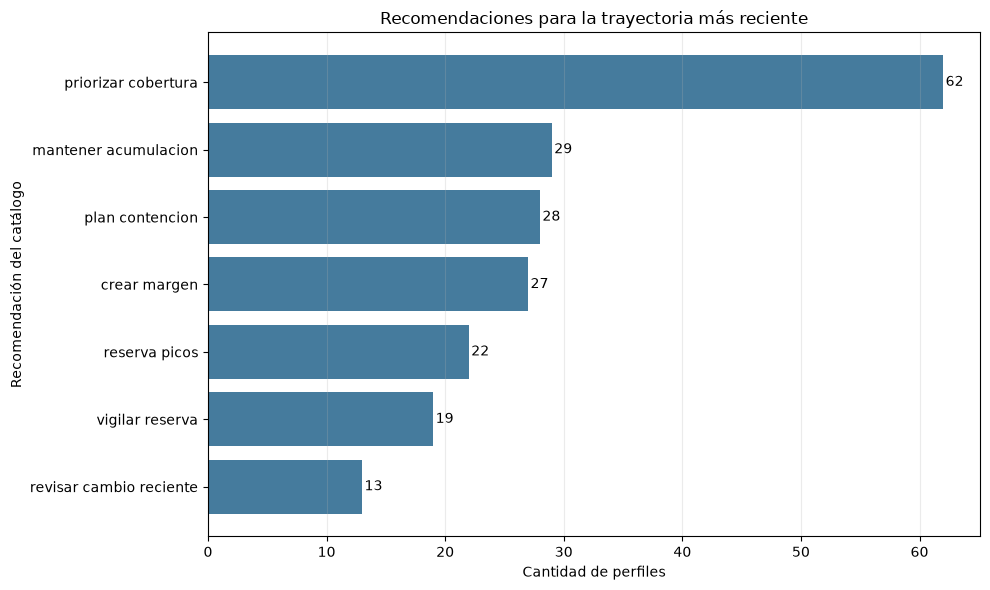

In [21]:
#Graficar recomendaciones
distribucion_recomendaciones = recomendaciones_actuales['recomendacion_id'].value_counts().sort_values()
etiquetas = [
    etiqueta.replace('REC_', '').replace('_', ' ').lower()
    for etiqueta in distribucion_recomendaciones.index
]

figura, eje = plt.subplots(figsize=(10, 6))
eje.barh(etiquetas, distribucion_recomendaciones.values, color='#457B9D')
eje.set_title('Recomendaciones para la trayectoria más reciente')
eje.set_xlabel('Cantidad de perfiles')
eje.set_ylabel('Recomendación del catálogo')
eje.grid(axis='x', alpha=0.25)

for posicion, valor in enumerate(distribucion_recomendaciones.values):
    eje.text(valor + 0.2, posicion, str(int(valor)), va='center')

figura.tight_layout()
figura.savefig(ruta_graficas / '05_distribucion_recomendaciones.png', dpi=180, bbox_inches='tight')
plt.show()

## 12. Serialización y exportación

In [20]:
#Guardar artefactos
ruta_modelo.parent.mkdir(parents=True, exist_ok=True)
ruta_resultados.mkdir(parents=True, exist_ok=True)

artefacto = {
    'version_modelo': VERSION_MODELO,
    'modelo': modelo_final,
    'variables_modelo': variables_modelo,
    'columnas_probabilidad': columnas_probabilidad,
    'catalogo_recomendaciones': catalogo_recomendaciones.reset_index().to_dict(orient='records'),
    'guardas_eticas': guardas_eticas.to_dict(orient='records'),
    'umbral_estado': UMBRAL_ESTADO,
    'umbral_recomendacion': UMBRAL_RECOMENDACION,
    'cobertura_esencial_minima_meses': COBERTURA_ESENCIAL_MINIMA_MESES,
    'metricas_validation': metricas_validation.to_dict(orient='records'),
    'metricas_test': metricas_test.to_dict(orient='records'),
    'limitacion': 'el dataset contiene una recomendación única por estado y no permite aprender un ranking de alternativas dentro del mismo estado',
    'principio_etico': 'las guardas tienen prioridad sobre la probabilidad del modelo',
}

joblib.dump(artefacto, ruta_modelo)

ruta_recomendaciones = ruta_resultados / '05_recomendaciones.csv'
ruta_metricas = ruta_resultados / '05_metricas_modelo.csv'
recomendaciones_actuales.to_csv(ruta_recomendaciones, index=False)
pd.concat([
    metricas_validation.assign(particion='validation'),
    metricas_test.assign(particion='test'),
], ignore_index=True).to_csv(ruta_metricas, index=False)

archivos_generados = pd.DataFrame([
    {'artefacto': 'motor serializado', 'ruta': str(ruta_modelo), 'filas': np.nan},
    {'artefacto': 'recomendaciones actuales', 'ruta': str(ruta_recomendaciones), 'filas': len(recomendaciones_actuales)},
    {'artefacto': 'métricas', 'ruta': str(ruta_metricas), 'filas': len(metricas_validation) + len(metricas_test)},
])

display(archivos_generados)

,artefacto,ruta,filas
0,motor serializado,../Modelos/05_motor_recomendaciones.joblib,NaN
1,recomendaciones actuales,../Resultados/05_recomendaciones.csv,200.0
2,métricas,../Resultados/05_metricas_modelo.csv,3.0


## 13. Pruebas manuales

In [22]:
#Probar trayectoria estable
test_estable_meta = {
    'estado_modelo': 'acumulacion_estable',
    'estado_calculo_modelo': 'calculado',
    'confianza_pct': 95.0,
    'cobertura_esencial_L_meses': 4.2,
    'periodo_desde': '2026-04-01',
    'periodo_hasta': '2026-06-30',
    'meta_relacionada': 'crear_fondo_emergencia',
    'hobbies_considerados': 'ciclismo | fotografia_y_video',
    'aspectos_protegidos': 'necesidades_esenciales | meta:crear_fondo_emergencia | hobbies:ciclismo|fotografia_y_video',
    'prob_acumulacion_estable_pct': 95.0,
    'prob_deterioro_reciente_pct': 0.5,
    'prob_equilibrio_sostenible_pct': 2.5,
    'prob_fragilidad_sostenida_pct': 0.3,
    'prob_situacion_critica_pct': 0.2,
    'prob_uso_planificado_reserva_pct': 0.5,
    'prob_variable_resiliente_pct': 1.0,
}

resultado_estable = generar_recomendacion(test_estable_meta)
display(pd.DataFrame([{
    'caso': 'estable_con_meta',
    'estado_motor': resultado_estable['estado_motor'],
    'recomendacion_id': resultado_estable['recomendacion_id'],
    'decision': resultado_estable['decision'],
    'confianza_pct': resultado_estable['confianza_recomendacion_pct'],
    'guardas': resultado_estable['guardas_aplicadas'],
}]))

display(pd.DataFrame([resultado_estable['porcentajes_recomendacion']]))
assert resultado_estable['recomendacion_id'] == 'REC_MANTENER_ACUMULACION'

,caso,estado_motor,recomendacion_id,decision,confianza_pct,guardas
0,estable_con_meta,recomendacion_disponible,REC_MANTENER_ACUMULACION,aplicar,94.58,[hobbies_no_eliminados_automaticamente]


,REC_MANTENER_ACUMULACION,REC_CREAR_MARGEN,REC_VIGILAR_RESERVA,REC_RESERVA_PICOS,REC_PRIORIZAR_COBERTURA,REC_REVISAR_CAMBIO_RECIENTE,REC_PLAN_CONTENCION
0,94.58,1.58,0.95,0.93,0.82,0.76,0.4


In [24]:
#Probar cobertura reducida
test_cobertura_reducida = {
    'estado_modelo': 'fragilidad_sostenida',
    'estado_calculo_modelo': 'calculado',
    'confianza_pct': 91.0,
    'cobertura_esencial_L_meses': 0.3,
    'periodo_desde': '2026-04-01',
    'periodo_hasta': '2026-06-30',
    'meta_relacionada': 'pagar_deuda',
    'hobbies_considerados': 'musica | impresion_3d',
    'aspectos_protegidos': 'vivienda | alimentacion | salud | hobbies:musica|impresion_3d',
    'prob_acumulacion_estable_pct': 0.2,
    'prob_deterioro_reciente_pct': 3.0,
    'prob_equilibrio_sostenible_pct': 0.3,
    'prob_fragilidad_sostenida_pct': 91.0,
    'prob_situacion_critica_pct': 4.0,
    'prob_uso_planificado_reserva_pct': 0.5,
    'prob_variable_resiliente_pct': 1.0,
}

resultado_cobertura = generar_recomendacion(test_cobertura_reducida)
display(pd.DataFrame([{
    'caso': 'cobertura_esencial_reducida',
    'estado_motor': resultado_cobertura['estado_motor'],
    'recomendacion_id': resultado_cobertura['recomendacion_id'],
    'decision': resultado_cobertura['decision'],
    'revision_humana': resultado_cobertura['revision_humana'],
    'guardas': resultado_cobertura['guardas_aplicadas'],
}]))

display(pd.DataFrame([resultado_cobertura['porcentajes_recomendacion']]))
assert resultado_cobertura['recomendacion_id'] == 'REC_PRIORIZAR_COBERTURA'
assert 'proteccion_esencial_por_fragilidad' in resultado_cobertura['guardas_aplicadas']

,caso,estado_motor,recomendacion_id,decision,revision_humana,guardas
0,cobertura_esencial_reducida,recomendacion_disponible,REC_PRIORIZAR_COBERTURA,aplicar,no_requerida,"[proteccion_esencial_por_fragilidad, hobbies_n..."


,REC_PRIORIZAR_COBERTURA,REC_CREAR_MARGEN,REC_REVISAR_CAMBIO_RECIENTE,REC_MANTENER_ACUMULACION,REC_RESERVA_PICOS,REC_VIGILAR_RESERVA,REC_PLAN_CONTENCION
0,96.33,2.3,0.63,0.4,0.21,0.12,0.02


In [23]:
#Probar evidencia insuficiente
test_evidencia_insuficiente = {
    'estado_modelo': 'no_disponible',
    'estado_calculo_modelo': 'evidencia_insuficiente',
    'confianza_pct': np.nan,
    'cobertura_esencial_L_meses': np.nan,
    'periodo_desde': '2026-06-30',
    'periodo_hasta': '2026-06-30',
    'meta_relacionada': 'crear_fondo_emergencia',
    'hobbies_considerados': 'ciclismo',
}

resultado_insuficiente = generar_recomendacion(test_evidencia_insuficiente)

display(pd.DataFrame([{
    'caso': 'evidencia_insuficiente',
    'estado_motor': resultado_insuficiente['estado_motor'],
    'recomendacion_id': resultado_insuficiente['recomendacion_id'],
    'decision': resultado_insuficiente['decision'],
    'motivos': resultado_insuficiente['motivos'],
    'porcentajes_recomendacion': resultado_insuficiente['porcentajes_recomendacion'],
}]))

assert resultado_insuficiente['estado_motor'] == 'abstencion'
assert resultado_insuficiente['recomendacion_id'] == 'no_disponible'
assert resultado_insuficiente['porcentajes_recomendacion'] == {}

,caso,estado_motor,recomendacion_id,decision,motivos,porcentajes_recomendacion
0,evidencia_insuficiente,abstencion,no_disponible,abstener,"[estado_financiero_sin_evidencia_suficiente, e...",{}
